In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import time
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

MODEL_PARAMS = {
    "patch_size": 16,  # 8, 16, 32, 64, 128
    "num_samples": 100,
    "target_dim": 1,
    "feat_dynamic_real_dim": 0,
    "past_feat_dynamic_real_dim": 0,
}

In [17]:
from exp_moirai.medium_utils import (
    generate_model_input,
    preprocess_data,
    get_predictions,
    plot_results,
    mean_absolute_percentage_error,
)

# forecast with Moirai

total length: 4581
Index(['target'], dtype='object')
time frequency: 1 days 00:00:00
2009-01-03 00:00:00 2021-07-19 00:00:00


<Axes: xlabel='date'>

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

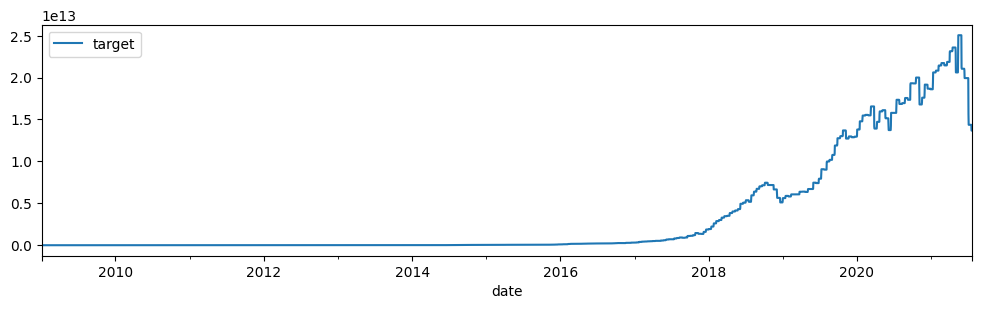

In [18]:
# First: Load dataframe and clean it
df = pd.read_csv(
    "https://raw.githubusercontent.com/anamabo/medium-blogs/main/moirai-moe/data/dataset1.csv"
)
date_colname = "date"
target_colname = "target"


df[date_colname] = pd.to_datetime(df[date_colname])
df.set_index(date_colname, inplace=True)  # Normalize the target variable

print(f"total length: {df.shape[0]}")
print(df.columns)
print(f"time frequency: {df.index.diff()[1]}")
print(df.index[0], df.index[-1])
df.plot(figsize=(12, 3))

In [19]:
# create the train and test sets
train_window = 12 * 365  # days
prediction_window = 90  # days

train = df.iloc[:train_window, :].copy()
test = df.iloc[train_window:, :].copy()

# preprocess the data
target_tensor, is_target_observed, is_target_padded = preprocess_data(
    target=train[target_colname].values
)

print(target_tensor.shape)
print(is_target_observed.shape)
print(is_target_padded.shape)

# Define the model
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-small"),
    prediction_length=prediction_window,
    context_length=train_window,
    **MODEL_PARAMS,
)

# Make the forecast
forecast = model(
    past_target=target_tensor,
    past_observed_target=is_target_observed,
    past_is_pad=is_target_padded,
)

# Collect the median forecast and CI into a DataFrame
predictions_df = get_predictions(
    forecast_tensor=forecast[0], train_set=train, date_colname=date_colname
)

# Merge predictions with original data
true_and_preds = pd.merge(
    test, predictions_df, left_index=True, right_index=True, how="right"
)
all_data = pd.concat([train.iloc[-365:, :], true_and_preds])

torch.Size([1, 4380, 1])
torch.Size([1, 4380, 1])
torch.Size([1, 4380])


---

### Test my Encoder

In [20]:
import torch
from encoder import MoiraiEncoder

encoder = MoiraiEncoder(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-small"),
    prediction_length=prediction_window,
    context_length=train_window,
    **MODEL_PARAMS,
)

In [21]:
reprs = encoder(
    past_target=target_tensor,
    past_observed_target=is_target_observed,
    past_is_pad=is_target_padded,
    feat_dynamic_real=None,
    observed_feat_dynamic_real=None,
    past_feat_dynamic_real=None,
    past_observed_feat_dynamic_real=None,
    num_samples=None,
)

Research on encoder

In [22]:
from exp_moirai.module_encoder import MoiraiModuleEncoder

encoder = MoiraiModuleEncoder.from_pretrained(f"Salesforce/moirai-1.1-R-small")

distr = model._get_distr(
    model.hparams.patch_size,
    past_target=target_tensor,
    past_observed_target=is_target_observed,
    past_is_pad=is_target_padded,
    feat_dynamic_real=None,
    observed_feat_dynamic_real=None,
    past_feat_dynamic_real=None,
    past_observed_feat_dynamic_real=None,
)

(
    target,
    observed_mask,
    sample_id,
    time_id,
    variate_id,
    prediction_mask,
) = model._convert(
    model.hparams.patch_size,
    past_target=target_tensor,
    past_observed_target=is_target_observed,
    past_is_pad=is_target_padded,
    feat_dynamic_real=None,
    observed_feat_dynamic_real=None,
    past_feat_dynamic_real=None,
    past_observed_feat_dynamic_real=None,
)

reprs = encoder(
    target,
    observed_mask,
    sample_id,
    time_id,
    variate_id,
    prediction_mask,
    torch.ones_like(time_id, dtype=torch.long) * model.hparams.patch_size,
)

preds = distr.sample(torch.Size((model.hparams.num_samples,)))
preds.shape, reprs.shape

(torch.Size([100, 1, 280, 128]), torch.Size([1, 280, 384]))

In [23]:
is_target_observed.shape, is_target_padded.shape

(torch.Size([1, 4380, 1]), torch.Size([1, 4380]))

In [24]:
reprs.shape

torch.Size([1, 280, 384])

---

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

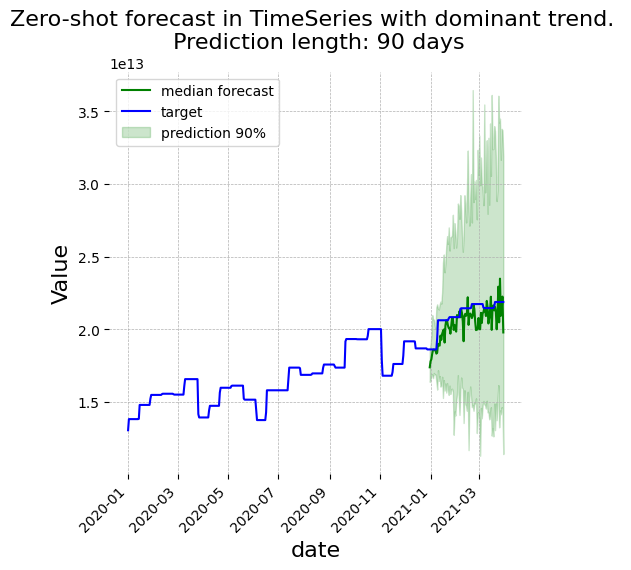

In [25]:
# # Plot the results
figure = plot_results(
    results_df=all_data,
    target_colname=target_colname,
    title=f"Zero-shot forecast in TimeSeries with dominant trend. \n Prediction length: {prediction_window} days",
    figsize=(5, 6),
)
plt.show()

In [26]:
# Compute the forecast error
true_and_preds.dropna(inplace=True)
mape = mean_absolute_percentage_error(
    y_true=true_and_preds[target_colname].values,
    y_pred=true_and_preds["median_forecast"].values,
)

print(mape)

3.493649404770159


## Patch size experiment

In [27]:
patches_list = [8, 16, 32, 64, 128]
train_window1 = 12 * 365  # days
prediction_window1 = 90
mape_list = []
time_list = []

train1 = df.iloc[:train_window1, :].copy()
test1 = df.iloc[train_window1:, :].copy()

for patch in patches_list:
    start_time = time.time()
    # preprocess the data
    target_tensor, is_target_observed, is_target_padded = preprocess_data(
        target=train1[target_colname].values
    )

    MODEL_PARAMS["patch_size"] = patch
    # Define the model
    model = MoiraiForecast(
        module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-small"),
        prediction_length=prediction_window1,
        context_length=train_window1,
        **MODEL_PARAMS,
    )

    # Make the forecast
    forecast = model(
        past_target=target_tensor,
        past_observed_target=is_target_observed,
        past_is_pad=is_target_padded,
    )

    # Collect the median forecast and CI into a DataFrame
    predictions_df = get_predictions(
        forecast_tensor=forecast[0], train_set=train1, date_colname=date_colname
    )

    # Merge predictions with original data
    true_and_preds = pd.merge(
        test1, predictions_df, left_index=True, right_index=True, how="right"
    )
    all_data = pd.concat([train1.iloc[-200:, :], true_and_preds])

    true_and_preds.dropna(inplace=True)
    mape = mean_absolute_percentage_error(
        y_true=true_and_preds[target_colname].values,
        y_pred=true_and_preds["median_forecast"].values,
    )
    end_time = time.time()
    elapsed_time = end_time - start_time
    mape_list.append(mape)
    time_list.append(elapsed_time)

mape_batch_size_df = pd.DataFrame(
    {"patch_size": patches_list, "mape": mape_list, "elapsed_time": time_list}
)
mape_batch_size_df

,patch_size,mape,elapsed_time
0,8,42.537063,2.241490
1,16,3.306259,1.662101
2,32,7.792494,1.040161
3,64,7.283529,0.888830
4,128,8.567042,0.795661


## Rolling forecast using predictions

total length: 4581
Index(['target'], dtype='object')
time frequency: 1 days 00:00:00
2009-01-03 00:00:00 2021-07-19 00:00:00


<Axes: xlabel='date'>

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

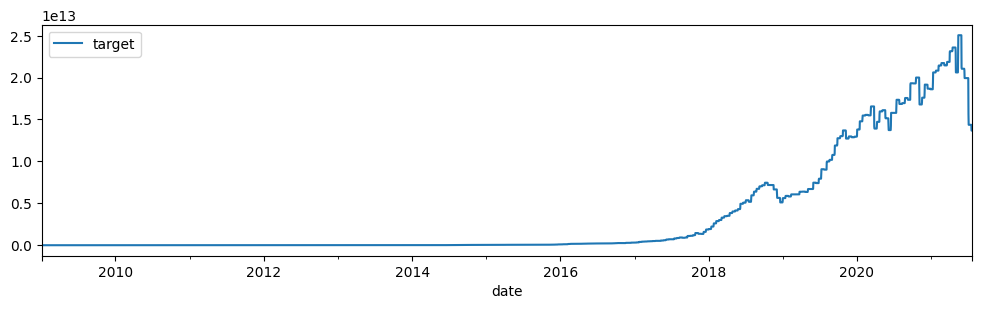

In [28]:
# First: Load dataframe

df = pd.read_csv(
    "https://raw.githubusercontent.com/anamabo/medium-blogs/main/moirai-moe/data/dataset1.csv"
)
date_colname = "date"
target_colname = "target"

df[date_colname] = pd.to_datetime(df[date_colname])
df.set_index(date_colname, inplace=True)

print(f"total length: {df.shape[0]}")
print(df.columns)

print(f"time frequency: {df.index.diff()[1]}")
print(df.index[0], df.index[-1])
df.plot(figsize=(12, 3))

In [29]:
# create the train and test sets
train_window = 12 * 365  # days
prediction_window = 30  # days
niter = 3  # iterations for the rolling forecast
MODEL_PARAMS["patch_size"] = 16

train = df.iloc[:train_window, :].copy()
test = df.iloc[train_window:, :].copy()

frequency = train.index.diff()[1]
train_original = train.copy()  # to be used for plotting

# Rolling forecast
all_predictions = []
for i in range(niter):
    print(f"interation: {i}")
    if i == 0:
        # Use the original train
        train = generate_model_input(
            train_df=train,
            date_colname=date_colname,
            target_colname=target_colname,
            median_forecast=None,
        )

    elif last_date_train + frequency * prediction_window in test.index:
        # In case you receive new input data (here represented by the test)
        train = generate_model_input(
            train_df=train,
            date_colname=date_colname,
            target_colname=target_colname,
            median_forecast=test.loc[
                last_date_train
                + frequency : last_date_train
                + frequency * prediction_window,
                target_colname,
            ].values,
        )

    else:
        # Use forecast to create another forecast
        train = generate_model_input(
            train_df=train,
            date_colname=date_colname,
            target_colname=target_colname,
            median_forecast=predictions_df["median_forecast"].values,
        )

    # Preprocess the new train set
    target_tensor, is_target_observed, is_target_padded = preprocess_data(
        target=train[target_colname].values
    )

    # Prepare model
    model = MoiraiForecast(
        module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-small"),
        prediction_length=prediction_window,
        context_length=train_window
        + i
        * prediction_window,  # Train context is not rolling, it always stars from the beginning
        **MODEL_PARAMS,
    )

    forecast = model(
        past_target=target_tensor,
        past_observed_target=is_target_observed,
        past_is_pad=is_target_padded,
    )

    predictions_df = get_predictions(
        forecast_tensor=forecast[0], train_set=train, date_colname=date_colname
    )
    last_date_train = predictions_df.index[-1]

    all_predictions.append(predictions_df)

all_predictions_df = pd.concat(all_predictions)

interation: 0
interation: 1
interation: 2


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

5.122023866332659


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


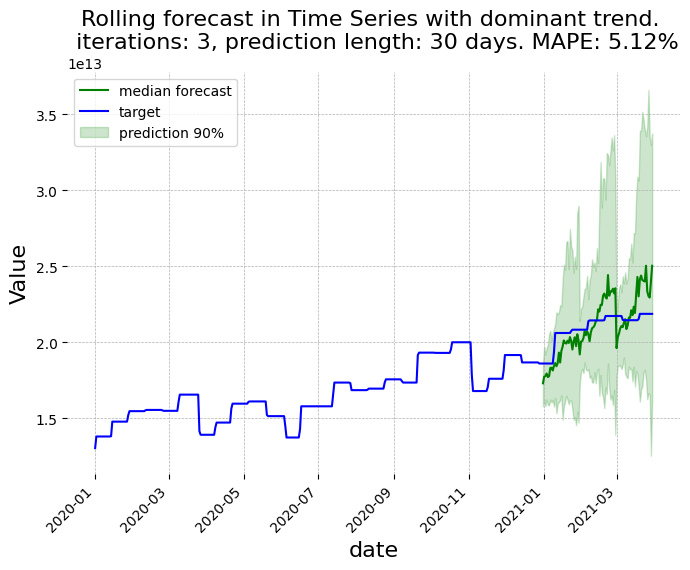

In [30]:
true_and_preds = pd.merge(
    test, all_predictions_df, left_index=True, right_index=True, how="right"
)
all_data = pd.concat([train_original.iloc[train_window - 365 :, :], true_and_preds])

# Get the forecast error
mape_rolling = mean_absolute_percentage_error(
    y_true=true_and_preds[target_colname].values,
    y_pred=true_and_preds["median_forecast"].values,
)

print(mape_rolling)

figure = plot_results(
    results_df=all_data,
    target_colname=target_colname,
    title=f"Rolling forecast in Time Series with dominant trend. \n iterations: {niter}, prediction length: {prediction_window} days. MAPE: {mape_rolling:.2f}%",
)
plt.show()